# 02. Approccio Classico: Feature HOG + LBP + Classificatore SVM
Questo notebook descrive l'implementazione dell'approccio classico per il riconoscimento delle espressioni facciali. Il processo prevede:
1. Estrazione di feature HOG (contorni e forme geometriche).
2. Estrazione di feature LBP (pattern locali di texture e micro-variazioni) calcolate cella per cella.
3. Concatenazione dei due vettori di caratteristiche.
4. Standardizzazione delle feature.
5. Addestramento di un classificatore SVM (Support Vector Machine) ottimizzato.
6. Valutazione e salvataggio del modello finalizzato.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Carichiamo il dataset pre-salvato
data_path = "../data/fer2013.npz"
if not os.path.exists(data_path):
    data_path = "data/fer2013.npz"

data = np.load(data_path)
X_train_raw, y_train = data["train_images"], data["train_labels"]
X_val_raw, y_val = data["val_images"], data["val_labels"]
X_test_raw, y_test = data["test_images"], data["test_labels"]

print(f"Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

Train: (25117, 48, 48), Val: (5380, 48, 48), Test: (5390, 48, 48)


## Estrazione delle Feature HOG e LBP
Implementiamo una funzione che combina:
- **HOG** con `orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)`, che produce 900 feature.
- **LBP** con `P=8, R=1` (metodo uniform). Calcoliamo poi l'istogramma LBP a 10 bin per ogni cella 8x8 (36 celle totali), ottenendo 360 feature.
Il vettore risultante avrà dimensione **1260**.

In [3]:
def extract_hog_lbp_features(img):
    # 1. Estrazione HOG (Gradienti orientati)
    hog_feats = hog(
        img, 
        orientations=9, 
        pixels_per_cell=(8, 8), 
        cells_per_block=(2, 2), 
        visualize=False
    )
    
    # 2. Estrazione LBP (Texture locale)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    
    # Calcolo dell'istogramma LBP per ogni cella 8x8 per mantenere l'informazione spaziale
    cell_size = 8
    lbp_feats = []
    for i in range(0, 48, cell_size):
        for j in range(0, 48, cell_size):
            cell = lbp[i:i+cell_size, j:j+cell_size]
            # Uniform LBP produce valori da 0 a 9
            hist, _ = np.histogram(cell, bins=10, range=(0, 10))
            hist = hist.astype(np.float32)
            # Normalizzazione dell'istogramma
            norm = np.linalg.norm(hist)
            if norm > 0:
                hist /= norm
            lbp_feats.extend(hist)
            
    lbp_feats = np.array(lbp_feats, dtype=np.float32)
    
    # Concatenazione HOG + LBP
    return np.concatenate([hog_feats, lbp_feats])

def extract_features_batch(images, desc):
    features = []
    for img in tqdm(images, desc=desc):
        features.append(extract_hog_lbp_features(img))
    return np.array(features, dtype=np.float32)

In [4]:
# Estrazione feature sui tre split
print("Avvio estrazione delle feature... (può richiedere circa 1-2 minuti)")
X_train_feats = extract_features_batch(X_train_raw, "Train Features")
X_val_feats = extract_features_batch(X_val_raw, "Val Features")
X_test_feats = extract_features_batch(X_test_raw, "Test Features")

print(f"Dimensioni feature estratte:")
print(f"Train: {X_train_feats.shape}, Val: {X_val_feats.shape}, Test: {X_test_feats.shape}")

Avvio estrazione delle feature... (può richiedere circa 1-2 minuti)


Train Features:   0%|          | 0/25117 [00:00<?, ?it/s]

Train Features:   0%|          | 92/25117 [00:00<00:27, 914.26it/s]

Train Features:   1%|          | 184/25117 [00:00<00:27, 913.66it/s]

Train Features:   1%|          | 276/25117 [00:00<00:27, 903.65it/s]

...

Test Features:  95%|█████████▌| 5145/5390 [00:05<00:00, 878.98it/s]

Test Features:  97%|█████████▋| 5236/5390 [00:05<00:00, 885.35it/s]

Test Features:  99%|█████████▉| 5326/5390 [00:06<00:00, 888.65it/s]

Test Features: 100%|██████████| 5390/5390 [00:06<00:00, 876.94it/s]

Dimensioni feature estratte:
Train: (25117, 1260), Val: (5380, 1260), Test: (5390, 1260)


## Standardizzazione dei Dati
Le SVM sono sensibili alla scala delle feature. Utilizziamo `StandardScaler` per normalizzare le caratteristiche con media 0 e varianza 1.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)
X_val_scaled = scaler.transform(X_val_feats)
X_test_scaled = scaler.transform(X_test_feats)

print("Standardizzazione completata.")

Standardizzazione completata.


## Ottimizzazione della SVM (Grid Search / Validation)
Addestriamo diversi modelli SVM lineari provando diversi valori del parametro di regolarizzazione $C$ sul validation set per trovare il miglior compromesso.

In [6]:
c_values = [0.01, 0.1, 1.0]
best_val_acc = 0.0
best_model = None
best_c = None

for c in c_values:
    print(f"Addestramento SVM con C={c}...")
    # Usiamo dual=False perché n_samples > n_features
    clf = LinearSVC(C=c, dual=False, max_iter=2000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Valutiamo sul validation set
    val_preds = clf.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, val_preds)
    print(f"  -> Accuratezza Validation: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = clf
        best_c = c

print(f"\nModello migliore trovato con C={best_c} (Acc: {best_val_acc:.4f})")

Addestramento SVM con C=0.01...


  -> Accuratezza Validation: 0.4541
Addestramento SVM con C=0.1...


  -> Accuratezza Validation: 0.4522
Addestramento SVM con C=1.0...


  -> Accuratezza Validation: 0.4476

Modello migliore trovato con C=0.01 (Acc: 0.4541)


## Valutazione sul Test Set
Valutiamo il miglior modello sul Test Set (PrivateTest) calcolando l'accuratezza totale, le metriche per classe e mostrando la matrice di confusione.

In [7]:
y_pred = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Accuratezza complessiva sul Test Set: {test_acc:.4f}\n")

EMOTIONS = {
    0: "Rabbia (Angry)",
    1: "Disgusto (Disgust)",
    2: "Paura (Fear)",
    3: "Felicità (Happy)",
    4: "Tristezza (Sad)",
    5: "Sorpresa (Surprise)",
    6: "Neutro (Neutral)"
}
target_names = [EMOTIONS[i] for i in range(7)]

print("Report di classificazione:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuratezza complessiva sul Test Set: 0.4527

Report di classificazione:
                     precision    recall  f1-score   support

     Rabbia (Angry)       0.37      0.28      0.31       744
 Disgusto (Disgust)       0.40      0.22      0.28        83
       Paura (Fear)       0.32      0.19      0.24       769
   Felicità (Happy)       0.56      0.76      0.65      1349
    Tristezza (Sad)       0.34      0.30      0.32       913
Sorpresa (Surprise)       0.50      0.56      0.53       601
   Neutro (Neutral)       0.42      0.46      0.44       931

           accuracy                           0.45      5390
          macro avg       0.42      0.40      0.40      5390
       weighted avg       0.43      0.45      0.43      5390



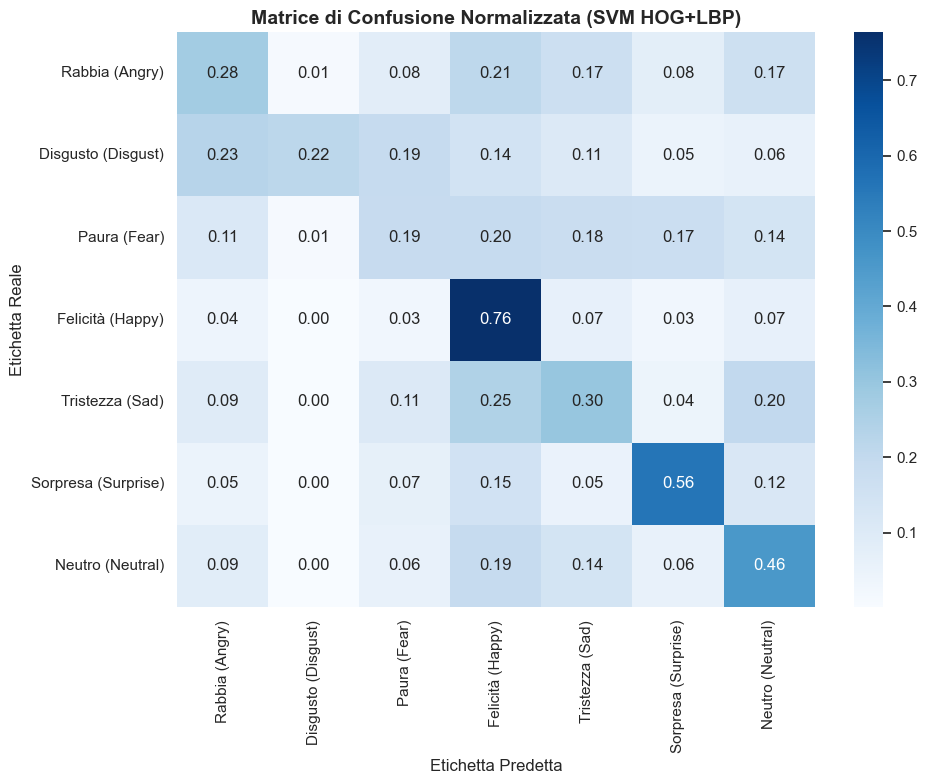

In [8]:
# Calcolo della matrice di confusione
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalizzata per riga

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=target_names, 
    yticklabels=target_names
)
plt.title("Matrice di Confusione Normalizzata (SVM HOG+LBP)", fontsize=14, fontweight='bold')
plt.ylabel("Etichetta Reale", fontsize=12)
plt.xlabel("Etichetta Predetta", fontsize=12)
plt.tight_layout()
plt.show()

## Salvataggio del Modello e dello Scaler
Salviamo lo scaler e il modello SVM addestrato in formato `.joblib`/`.pkl` nella cartella `models/` in modo da poterli ricaricare nella demo in tempo reale.

In [9]:
os.makedirs("../models", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Salvataggio su file
models_dir = "../models" if os.path.exists("../models") else "models"
model_file = os.path.join(models_dir, "svm_model.pkl")
scaler_file = os.path.join(models_dir, "svm_scaler.pkl")

joblib.dump(best_model, model_file)
joblib.dump(scaler, scaler_file)

print(f"Modello salvato in: {model_file}")
print(f"Scaler salvato in: {scaler_file}")

Modello salvato in: ../models/svm_model.pkl
Scaler salvato in: ../models/svm_scaler.pkl
